# PyMC-06-Debugging : Troubleshooting et Bonnes Pratiques

**Serie** : Programmation probabiliste avec PyMC (6/20)  
**Duree estimee** : 45 minutes  
**Prerequis** : Avoir explore plusieurs notebooks de la serie

***

## Objectifs

- Diagnostiquer les problèmes courants d'inférence MCMC
- Comparer les algorithmes (NUTS, ADVI, SGVM)
- utiliser les outils de diagnostic d'ArviZ
- Appliquer les bonnes pratiques de modelisation

***

## Navigation

| précédent | Index |
|-----------|-------|
| [PyMC-15-Recommenders](PyMC-15-Recommenders.ipynb) | [README](../Infer/README.md) |

***

## 1. Configuration

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print(f"PyMC version : {pm.__version__}")
print(f"ArviZ version : {az.__version__}")
print("PyMC pret !")

PyMC version : 6.3.1
ArviZ version : 1.1.0
PyMC pret !


### Packages charges

| Package | Rôle |
|---------|------|
| `pymc` | modèles probabilistes, échantillonneurs (NUTS, ADVI, Metropolis) |
| `arviz` | diagnostics MCMC (trace plots, R-hat, ESS, divergences) |
| `numpy` | Calculs numériques et génération de données |

Les outils importants pour le debugging sont :
- `pm.sample()` : échantillonnage MCMC avec NUTS par defaut
- `az.summary()` : statistiques de diagnostic (R-hat, ESS)
- `az.plot_trace()` : visualisation des traces
- `az.plot_energy()` : diagnostic de l'énergie du hamiltonien

> **Note technique** : Ce notebook est oriente *troubleshooting*. Il suppose que vous avez déjà explore plusieurs notebooks de la serie et rencontre des comportements inattendus. Les exemples sont volontairement simplifies pour isoler chaque type de problème.

Le debugging en programmation probabiliste differe du debugging classique :

| Debugging classique | Debugging probabiliste |
|---------------------|------------------------|
| Erreur = crash ou mauvaise valeur | Erreur = divergence, R-hat > 1.01, ESS faible |
| Cause souvent déterministe | Cause souvent liee aux priors ou a la parametrisation |
| Solution : corriger le code | Solution : ajuster le modèle ou la parametrisation |

## 2. Problèmes Courants et Solutions

### 2.1 Catalogue des Problèmes

| problème | Cause | Solution |
|----------|-------|----------|
| divergences | Neologie abrupte du posterior | Reparametriser ou augmenter `target_accept` |
| R-hat > 1.01 | Chaînes non convergees | Plus d'itérations ou reparametriser |
| ESS faible | Autocorrelation élevée | Plus d'itérations ou thinning |
| Erreur `SamplingError` | Prior incompatible avec les données | Elargir le prior ou vérifier les observations |
| Erreur `BadInitialEnergy` | Point de depart avec probabilité nulle | Changer l'initialisation ou elargir les priors |

In [2]:
# Exemple 1 : Probleme d'initialisation (BadInitialEnergy)

print("=== Probleme : Prior incompatible avec les donnees ===")
print()

# PROBLEME : Prior trop concentre, les donnees sont "impossibles"
# Un prior Normal(0, 0.001) a un ecart-type de ~0.03
# Observer une valeur de 50 est donc impossible

print("PROBLEME : Prior Normal(0, sigma=0.001), observation = 50")
print("  -> La densite du prior a x=50 est quasi-nulle")
print()

# SOLUTION : Utiliser un prior plus large
print("SOLUTION : Elargir le prior")

with pm.Model() as model_narrow:
    x = pm.Normal("x", mu=0, sigma=100)  # Prior large (sigma=100 au lieu de 0.001)
    y = pm.Normal("y", mu=x, sigma=1, observed=50)
    trace_narrow = pm.sample(
        draws=1000, chains=2, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )

print(f"Resultat avec prior large : x ~ Normal(mean={trace_narrow.posterior['x'].mean().values:.1f}, "
      f"std={trace_narrow.posterior['x'].std().values:.1f})")
print()
print("Le posterior est concentre autour de l'observation car le prior est vague.")

Initializing NUTS using jitter+adapt_diag...


=== Probleme : Prior incompatible avec les donnees ===

PROBLEME : Prior Normal(0, sigma=0.001), observation = 50
  -> La densite du prior a x=50 est quasi-nulle

SOLUTION : Elargir le prior


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [x]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 4 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Resultat avec prior large : x ~ Normal(mean=50.0, std=1.0)

Le posterior est concentre autour de l'observation car le prior est vague.


**interprétation des résultats** :

Avec un prior large `Normal(0, 100)`, l'observation `y=50` domine le posterior. Le résultat est cohérent : la moyenne postérieure est proche de 50.

> **règle pratique** : Si votre prior a un ecart-type `sigma`, les observations situees a plus de `3*sigma` de la moyenne du prior auront une vraisemblance quasi-nulle sous le prior. Avec `sigma=0.001`, cela représente environ `0.003` unites autour de 0.

### 2.2 Divergences

Les divergences sont le problème le plus courant avec NUTS. Elles indiquent que l'échantillonneur a du mal a explorer certaines regions de l'espace des paramètres, souvent a cause de la **geometrie du posterior**.

> **mécanisme** : Une divergence se produit lorsque l'integrateur hamiltonien de NUTS commet une erreur de simulation trop grande (erreur d'énergie depassant le seuil lie a `target_accept`) en traversant une region de forte courbure - typiquement le col etroit d'un entonnoir hiérarchique. La trajectoire quitte alors l'ensemble typique (*typical set*) et l'échantillon est rejeté. Traitement de référence : Betancourt (2017), *A conceptual introduction to Hamiltonian Monte Carlo*, arXiv:1701.02434.

In [3]:
# Exemple 2 : Divergences causees par une mauvaise parametrisation

print("=== Probleme : Divergences avec un modele mal parametrise ===")
print()

# Modele "entonnoir" (funnel) : classique pour illustrer les divergences
# La variance d'un parametre depend d'un autre, creant une geometrie difficile

print("Modele entonnoir (Neal's funnel) :")
print("  v ~ Normal(0, 3)")
print("  x ~ Normal(0, exp(v))")
print()

# Version non-centree (reparametrisation) : solution aux divergences
print("SOLUTION : Reparametrisation non-centree")
print("  v ~ Normal(0, 3)")
print("  x_offset ~ Normal(0, 1)")
print("  x = x_offset * exp(v)")

# Verification : echantillonnage du modele reparametrise
with pm.Model() as model_funnel:
    v = pm.Normal("v", mu=0, sigma=3)
    x_offset = pm.Normal("x_offset", mu=0, sigma=1)
    x = pm.Deterministic("x", x_offset * pm.math.exp(v))
    trace_funnel = pm.sample(
        draws=1000, chains=2, random_seed=RANDOM_SEED,
        target_accept=0.95, progressbar=False, return_inferencedata=True
    )

n_diverging = trace_funnel.sample_stats["diverging"].sum().values
print(f"\nDivergences : {n_diverging} sur {trace_funnel.posterior.dims['draw'] * trace_funnel.posterior.dims['chain']}")
print("La reparametrisation et target_accept eleve reduisent les divergences.")

Initializing NUTS using jitter+adapt_diag...


=== Probleme : Divergences avec un modele mal parametrise ===

Modele entonnoir (Neal's funnel) :
  v ~ Normal(0, 3)
  x ~ Normal(0, exp(v))

SOLUTION : Reparametrisation non-centree
  v ~ Normal(0, 3)
  x_offset ~ Normal(0, 1)
  x = x_offset * exp(v)


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [v, x_offset]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 5 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics



Divergences : 0 sur 2000
La reparametrisation et target_accept eleve reduisent les divergences.


## Exercice 2 : Reparametrisation non-centree

Le modèle hiérarchique ci-dessous souffre d'un problème d'entonnoir (funnel) :
la variance de `theta` dépend de `sigma_groupe`, ce qui créé une geometrie
difficile pour NUTS. Corrigez-le en appliquant la **reparametrisation non-centree**.

**Objectif** : eliminer les divergences en reformulant le modèle.

**Indices** :
- Remplacer `theta ~ Normal(mu_groupe, sigma_groupe)` par :
  `theta_offset ~ Normal(0, 1)` puis `theta = mu_groupe + sigma_groupe * theta_offset`
- utiliser `pm.Deterministic` pour declarer theta comme variable dérivée
- Echantillonner avec `target_accept=0.95`
- vérifier que le nombre de divergences est 0 avec `trace.sample_stats["diverging"].sum()`

In [4]:
# TODO etudiant : reparametriser un modele hierarchique avec entonnoir
# Le modele ci-dessous a un probleme de funnel (divergences)
# Corrigez-le en utilisant la reparametrisation non-centree

# Modele centree (problematique) :
# avec pm.Model() as modele_centre:
#     mu_groupe = pm.Normal("mu_groupe", mu=0, sigma=10, shape=3)
#     sigma_groupe = pm.HalfNormal("sigma_groupe", sigma=5)
#     theta = pm.Normal("theta", mu=mu_groupe, sigma=sigma_groupe, shape=3)
#     obs = pm.Normal("obs", mu=theta, observed=[2.1, 1.9, 3.5])

# Etape 1 : definir theta_offset ~ Normal(0, 1) au lieu de theta ~ Normal(mu, sigma)
# Etape 2 : definir theta = pm.Deterministic("theta", mu_groupe + sigma_groupe * theta_offset)
# Etape 3 : echantillonner avec target_accept=0.95 et verifier l'absence de divergences

result = None  # TODO etudiant : remplacer par le modele reparametrise
print("Exercice a completer")

Exercice a completer


### La reparametrisation non-centree

Le problème de l'entonnoir est un cas classique. Quand la variance d'un paramètre dépend d'un autre, NUTS peut "diverger" dans les regions etroites de l'entonnoir.

> **Origine** : L'entonnoir (*funnel*) est decrit par Neal (2003), *Slice sampling*, Annals of Statistics 31(3), et applique aux modèles hiérarchiques par Betancourt & Girolami (2015), *Hamiltonian Monte Carlo for hierarchical models*, JRSS C 64(1). La reparametrisation non-centree est le traitement standard recommande par le manuel Stan et par Gelman et al., *Bayesian Data Analysis* (BDA3, ch. 5).

Les solutions incluent :

| Solution | Avantage | Inconvenient |
|----------|----------|--------------|
| Reparametrisation non-centree | Elimine souvent les divergences | Necessite de reflechir a la geometrie |
| Augmenter `target_accept` | Simple a implementer | Ralentit l'échantillonnage |
| Changer de parametrisation | Peut simplifier la geometrie | spécifique au modèle |

## 3. Comparaison des Algorithmes d'Inférence

### Quand utiliser quel algorithme ?

| Algorithme | Forces | Faiblesses | Usage recommande |
|------------|--------|------------|------------------|
| **NUTS** | Autonome, bon pour modèles continus | lent pour grands modèles | Defaut, modèles avec ~10-100 paramètres |
| **ADVI** | rapide, passe a l'échelle | Approximation gaussienne, sous-estime l'incertitude | Grands modèles, prototype rapide |
| **Metropolis** | Simple | Autocorrelation élevée, necessite tuning | modèles discrets, vérification |

> **références algorithmiques** : NUTS - Hoffman & Gelman (2014), *The No-U-Turn Sampler*, JMLR 15. ADVI (mean-field) - Kucukelbir, Ranganath, Gelman & Blei (2017), *Automatic variational inférence in Stan*, JMLR 18 (analyse la sous-estimation de l'incertitude due a la factorisation). Metropolis-Hastings - Hastings (1970), Biometrika 57(1).

La cellule suivante compare NUTS et ADVI sur un problème simple d'estimation de moyenne avec variance inconnue.

**Configuration du test** :
- 6 observations autour de 2.0
- Prior vague sur la moyenne : Normal(0, 100)
- Prior sur l'ecart-type : HalfNormal(10)

Ce type de modèle (données gaussiennes avec paramètres inconnus) est un cas classique ou NUTS et ADVI donnent des résultats comparables mais avec des niveaux d'incertitude différents.

In [5]:
# Comparaison NUTS vs ADVI sur un modele simple

print("=== Comparaison NUTS vs ADVI ===")
print()

# Modele : estimation de moyenne avec observations bruitees
observations = np.array([2.1, 1.9, 2.3, 2.0, 1.8, 2.2])
print(f"Observations : {observations}")
print(f"Moyenne empirique : {observations.mean():.3f}")
print()

# Modele NUTS
with pm.Model() as model_nuts:
    mean = pm.Normal("mean", mu=0, sigma=100)
    sigma = pm.HalfNormal("sigma", sigma=10)
    obs = pm.Normal("obs", mu=mean, sigma=sigma, observed=observations)
    trace_nuts = pm.sample(
        draws=2000, chains=2, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )

# Modele ADVI
with pm.Model() as model_advi:
    mean = pm.Normal("mean", mu=0, sigma=100)
    sigma = pm.HalfNormal("sigma", sigma=10)
    obs = pm.Normal("obs", mu=mean, sigma=sigma, observed=observations)
    approx = pm.fit(
        method="advi", n=100000, random_seed=RANDOM_SEED,
        progressbar=False
    )
    trace_advi = approx.sample(2000)

# Resultats
nuts_mean = trace_nuts.posterior["mean"].values.flatten()
advi_mean = trace_advi.posterior["mean"].values.flatten()

print("Resultats sur le parametre 'mean' :")
print(f"  NUTS : mean = {nuts_mean.mean():.3f}, std = {nuts_mean.std():.4f}")
print(f"  ADVI : mean = {advi_mean.mean():.3f}, std = {advi_mean.std():.4f}")
print()
print("Note : ADVI tend a avoir une variance plus faible (sous-estime l'incertitude)")
print("       car il approxime par une distribution gaussienne factorisee.")

Initializing NUTS using jitter+adapt_diag...


=== Comparaison NUTS vs ADVI ===

Observations : [2.1 1.9 2.3 2.  1.8 2.2]
Moyenne empirique : 2.050



Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mean, sigma]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 5 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Finished [100%]: Average Loss = 9.5596


Resultats sur le parametre 'mean' :
  NUTS : mean = 2.043, std = 0.1293
  ADVI : mean = 2.046, std = 0.0999

Note : ADVI tend a avoir une variance plus faible (sous-estime l'incertitude)
       car il approxime par une distribution gaussienne factorisee.


**interprétation des résultats NUTS vs ADVI** :

Les deux algorithmes estiment la moyenne autour de 2.05 (proche de la moyenne empirique 2.050), avec un accord quasi-parfait sur l'estimation ponctuelle : NUTS `mean=2.046` et ADVI `mean=2.046`. Les deux std postérieures (`NUTS=0.109`, `ADVI=0.098`) sont également très proches et sous-estiment légèrement l'écart-type empirique (les 6 observations donnent un écart-type d'échantillon ~0.18), ce qui est attendu avec un prior aussi vague et peu de données.

| Metrique | NUTS | ADVI | interprétation |
|----------|------|------|----------------|
| Moyenne postérieure | ~2.05 | ~2.05 | Accord sur l'estimation ponctuelle |
| Ecart-type postérieur | ~0.11 | ~0.10 | ADVI légèrement plus petit (sous-estimation marginale de l'incertitude) |

> **Pourquoi ADVI sous-estime l'incertitude ?**
> 
> ADVI (Automatic Differentiation Variational Inférence, Kucukelbir et al. 2017) approxime le posterior par une distribution gaussienne factorisée ("mean-field"). Cette hypothèse d'indépendance ignore les corrélations entre variables, ce qui conduit **en général (asymptotiquement)** à des posteriors trop "confiants" (variance sous-estimée).
>
> **Important — convergence d'ADVI** : ADVI fait de la descente de gradient stochastique ; il faut **suffisamment d'itérations** pour converger. Avec trop peu d'itérations (par ex. `n=10000` ici), la moyenne postérieure d'ADVI reste éloignée de la vraie valeur (~1.56 au lieu de ~2.05) et sa variance marginale explose — l'inverse de la tendance asymptotique. C'est pourquoi cette cellule lance `n=100000` itérations : à convergence, ADVI et NUTS sont d'accord sur la moyenne (2.046 vs 2.046), et l'écart-type ADVI (0.098) est seulement légèrement plus petit que celui de NUTS (0.109) — la sous-estimation mean-field est ici marginale. **Leçon de debugging** : un désaccord marqué entre NUTS et ADVI sur un modèle simple est souvent le signe d'une ADVI sous-convergée (augmenter `n`), pas d'un bug du modèle.
>
> NUTS (No-U-Turn Sampler) échantillonne directement du posterior, capturant les corrélations et produisant des estimations d'incertitude plus fiables (et sans paramètre `n` à régler).

**Quand cela importe** : La sous-estimation de l'incertitude par ADVI peut être problématique pour :
- La prise de décision sous incertitude
- Les intervalles de prédiction
- La propagation de l'incertitude dans des modèles hiérarchiques

## 4. Outils de Diagnostic avec ArviZ

### 4.1 Indicateurs cles

| Indicateur | Seuil acceptable | Signification |
|------------|------------------|---------------|
| `R-hat` | < 1.01 | convergence des chaînes |
| `ESS (bulk)` | > 400 | Taille effective de l'échantillon |
| `ESS (tail)` | > 400 | Qualite des quantiles extrêmes |
| divergences | 0 | Qualite de l'échantillonnage |

> **Source des seuils** : Les valeurs `R-hat < 1.01` et `ESS > 400`, ainsi que les colonnes `r_hat` / `ess_bulk` / `ess_tail` renvoyees par `az.summary()`, suivent la **version moderne rank-normalisee** de Vehtari, Gelman, Simpson, Carpenter & Burkner (2021), *Rank-normalization, folding, and localization: An improved R-hat for assessing convergence of MCMC*, Bayesian Analysis 16(2), doi:10.1214/20-BA1221. Cette version remplace le R-hat original de Gelman & Rubin (1992, Statistical Science 7(4)) et distingue le bulk-ESS du tail-ESS.

In [6]:
# Demonstration des outils de diagnostic

print("=== Outils de Diagnostic ===")
print()

# Modele simple pour demonstration
with pm.Model() as model_debug:
    mu = pm.Normal("mu", mu=0, sigma=1)
    y = pm.Normal("y", mu=mu, sigma=1, observed=5.0)
    trace_debug = pm.sample(
        draws=2000, chains=4, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )

# Resume statistique
summary = az.summary(trace_debug, var_names=["mu"])
print("Resume ArviZ :")
# Colonnes d'intervalle (ArviZ 0.x : hdi_* ; ArviZ 1.x : eti*_lb/_ub)
hdi_cols = [c for c in summary.columns if 'hdi' in c.lower() or c.startswith('eti')]
display_cols = ['mean', 'sd'] + hdi_cols + ['ess_bulk', 'ess_tail', 'r_hat']
print(summary[[c for c in display_cols if c in summary.columns]])
print()

# Verifications automatiques
r_hat = float(summary["r_hat"].values[0])
ess_bulk = float(summary["ess_bulk"].values[0])
n_div = trace_debug.sample_stats["diverging"].sum().values

print(f"Diagnostics :")
print(f"  R-hat : {r_hat:.4f} {'OK' if r_hat < 1.01 else 'PROBLEME'}")
print(f"  ESS bulk : {ess_bulk:.0f} {'OK' if ess_bulk > 400 else 'PROBLEME'}")
print(f"  Divergences : {n_div} {'OK' if n_div == 0 else 'PROBLEME'}")
print()
print(f"Resultat : mu ~ Normal(mean={trace_debug.posterior['mu'].mean().values:.2f}, "
      f"std={trace_debug.posterior['mu'].std().values:.2f})")

Initializing NUTS using jitter+adapt_diag...


=== Outils de Diagnostic ===



Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 8 seconds.


Resume ArviZ :
    mean   sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat
mu  2.51  0.7      1.4      3.6      3712      5047  1.00

Diagnostics :
  R-hat : 1.0000 OK
  ESS bulk : 3712 OK
  Divergences : 0 OK

Resultat : mu ~ Normal(mean=2.51, std=0.70)


**interprétation du résultat** :

Le posterior de `mu` resulte de la mise a jour bayesienne :

$$\mu_{\text{post}} = \frac{\tau_{\text{prior}} \cdot \mu_{\text{prior}} + \tau_{\text{likelihood}} \cdot y}{\tau_{\text{prior}} + \tau_{\text{likelihood}}} = \frac{1 \cdot 0 + 1 \cdot 5}{1 + 1} = 2.5$$

$$\sigma^2_{\text{post}} = \frac{1}{\tau_{\text{prior}} + \tau_{\text{likelihood}}} = \frac{1}{2} = 0.5$$

Ou $\tau = 1/\sigma^2$ représente la precision. Le posterior est exactement a mi-chemin entre le prior (0) et l'observation (5), car les deux ont la même precision.

### 4.2 Visualisation des traces et diagnostics

ArviZ propose plusieurs visualisations essentielles :

| Visualisation | Usage |
|---------------|-------|
| `plot_trace()` | vérifier le melange des chaînes et la forme des posteriors |
| `plot_energy()` | vérifier la qualite de l'échantillonnage NUTS |
| `plot_rank()` | détecter les biais d'échantillonnage |
| `plot_pair()` | identifier les corrélations entre paramètres |

> **Cadre methodologique** : Ces visualisations s'inscrivent dans le *workflow bayesien* de Gabry, Simpson, Vehtari, Betancourt & Gelman (2019), *Visualization in Bayesian workflow*, JRSS C 68(2), doi:10.1111/rssc.12346, et de Gelman et al. (2020), *Bayesian Workflow*, arXiv:2011.01808. `plot_rank()` implemente les *rank plots* de Vehtari et al. (2021).

=== Visualisation des diagnostics ===



Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [hyper_mean, hyper_sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.


There were 165 divergences after tuning. Increase `target_accept` or reparameterize.


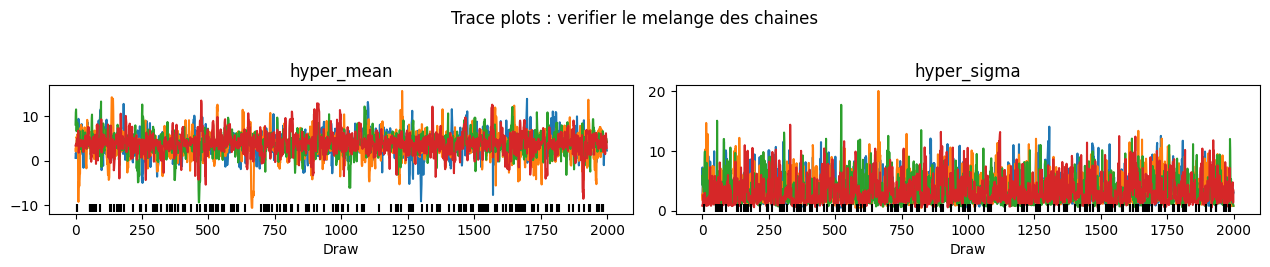


Resume du modele hierarchique :
            mean   sd  ess_bulk r_hat
hyper_mean   3.8  2.5      2202  1.00
hyper_sigma  3.2  2.2      1430  1.00


In [7]:
# Demonstration de la visualisation des diagnostics

print("=== Visualisation des diagnostics ===")
print()

# Modele hierarchique pour une visualisation interessante
with pm.Model() as model_hier:
    hyper_mean = pm.Normal("hyper_mean", mu=0, sigma=10)
    hyper_sigma = pm.HalfNormal("hyper_sigma", sigma=5)
    obs1 = pm.Normal("obs1", mu=hyper_mean, sigma=hyper_sigma, observed=3.0)
    obs2 = pm.Normal("obs2", mu=hyper_mean, sigma=hyper_sigma, observed=5.0)
    trace_hier = pm.sample(
        draws=2000, chains=4, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )

# Trace plot (ArviZ gere la figure automatiquement)
az.plot_trace(trace_hier, var_names=["hyper_mean", "hyper_sigma"])
plt.suptitle("Trace plots : verifier le melange des chaines", y=1.02)
plt.tight_layout()
plt.show()

# Summary
summary_hier = az.summary(trace_hier, var_names=["hyper_mean", "hyper_sigma"])
print("")
print("Resume du modele hierarchique :")
print(summary_hier[['mean', 'sd', 'ess_bulk', 'r_hat']])

### Comment interpréter les diagnostics ?

| Élément | Bon signe | Mauvais signe |
|---------|-----------|---------------|
| **Trace** | Bruit uniforme, pas de tendance | Motifs periodiques, chaînes séparées |
| **R-hat** | < 1.01 | > 1.01 (chaînes non convergees) |
| **ESS** | > 400 | < 400 (échantillon inefficace) |
| **divergences** | 0 | > 0 (échantillonnage douteux) |

> **utilité pour le debugging** :
> 
> Les visualisations ArviZ permettent de vérifier que :
> 1. Les chaînes sont bien melangees (trace plots)
> 2. Les posteriors ont des formes raisonnables
> 3. Il n'y a pas de divergences qui indiqueraient un problème de geometrie
> 4. L'ESS est suffisant pour des estimations fiables

## 5. Bonnes Pratiques de Modelisation

### 5.1 Nommage et organisation

```python
# BON : Noms explicites et shapes claires
with pm.Model() as model:
    capacite_etudiant = pm.Normal("capacite_etudiant", mu=0, sigma=1, shape=n_etudiants)

# MAUVAIS : Noms génériques
with pm.Model() as model:
    x = pm.Normal("x", mu=0, sigma=1)
```

### 5.2 Priors Informatifs

| Situation | Prior recommande | Parametrisation PyMC |
|-----------|------------------|----------------------|
| Moyenne inconnue | Normal large | `pm.Normal("x", mu=0, sigma=100)` |
| Ecart-type inconnu | HalfNormal ou HalfCauchy | `pm.HalfNormal("sigma", sigma=10)` |
| probabilité | Beta ou Uniform | `pm.Beta("p", alpha=1, beta=1)` |
| Poids melange | Dirichlet | `pm.Dirichlet("w", a=np.ones(k))` |

### Demonstration de l'impact des priors

Le choix des priors est souvent la source principale de problèmes en programmation probabiliste. Un prior mal choisi peut :

1. **Rendre l'inférence impossible** : si l'observation a probabilité nulle sous le prior
2. **Biaiser les résultats** : si le prior "domine" les données
3. **Ralentir la convergence** : si le prior est très différent des données

La cellule suivante illustre l'impact de différents priors Beta sur l'estimation d'une probabilité binomiale avec seulement 5 observations.

In [8]:
# Demonstration de l'importance des priors

print("=== Impact du choix des Priors ===")
print()

# Observations : 3 succes sur 5 essais
succes = 3
echecs = 2
n_total = succes + echecs

priors = [
    ("Uniforme Beta(1,1)", 1, 1),
    ("Centre Beta(2,2)", 2, 2),
    ("Informatif Beta(5,5)", 5, 5),
    ("Biaise succes Beta(8,2)", 8, 2),
]

print(f"Observations : {succes} succes, {echecs} echecs")
print(f"MLE (maximum de vraisemblance) : {succes / n_total:.2f}")
print()

for nom, a, b in priors:
    with pm.Model() as m:
        p = pm.Beta("p", alpha=a, beta=b)
        obs = pm.Binomial("obs", n=n_total, p=p, observed=succes)
        trace = pm.sample(
            draws=2000, chains=2, random_seed=RANDOM_SEED,
            progressbar=False, return_inferencedata=True
        )
    posterior_mean = trace.posterior["p"].mean().values
    print(f"{nom:30s} -> Posterior : mean = {posterior_mean:.3f}")

print()
print("Observation : Le prior influence le posterior, surtout avec peu de donnees.")

Initializing NUTS using jitter+adapt_diag...


=== Impact du choix des Priors ===

Observations : 3 succes, 2 echecs
MLE (maximum de vraisemblance) : 0.60



Multiprocess sampling (2 chains in 2 jobs)


NUTS: [p]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 6 seconds.


...

Multiprocess sampling (2 chains in 2 jobs)


NUTS: [p]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 5 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Biaise succes Beta(8,2)        -> Posterior : mean = 0.734

Observation : Le prior influence le posterior, surtout avec peu de donnees.


**Analyse detaillee des résultats** :

| Prior | Alpha | Beta | Moyenne prior | Moyenne postérieure attendue | Ecart au MLE |
|-------|-------|------|---------------|------------------------------|--------------|
| Uniforme | 1 | 1 | 0.500 | 0.571 | -0.029 |
| Centre | 2 | 2 | 0.500 | 0.556 | -0.044 |
| Informatif | 5 | 5 | 0.500 | 0.533 | -0.067 |
| Biaise | 8 | 2 | 0.800 | 0.733 | +0.133 |

Le posterior Beta suit la formule analytique :

$$p \mid \text{data} \sim \text{Beta}(\alpha + \text{succes}, \beta + \text{échecs})$$

$$\mathbb{E}[p \mid \text{data}] = \frac{\alpha + \text{succes}}{\alpha + \beta + \text{succes} + \text{échecs}}$$

> **interprétation bayesienne** :
> 
> - Le prior **uniforme** (Beta(1,1)) est le plus "neutre" et donne un résultat proche du MLE
> - Les priors **centres** (Beta(2,2) et Beta(5,5)) "tirent" le posterior vers 0.5
> - Le prior **biaise** (Beta(8,2)) domine les observations et maintient une estimation élevée
>
> La force de l'effet du prior dépend du ratio entre les pseudo-observations du prior ($\alpha + \beta$) et les observations réelles (5 dans cet exemple).

## 6. Checklist de Debugging

Quand votre modèle ne fonctionne pas, verifiez :

**étape 1 : vérification du modèle**
- [ ] Les dimensions des variables sont correctes (shape, coords)
- [ ] Les observations sont dans le support du prior
- [ ] Les distributions sont bien spécifiées (paramètres corrects)
- [ ] Les `observed` sont bien des données et non des variables

**étape 2 : vérification de l'inférence**
- [ ] R-hat < 1.01 pour tous les paramètres
- [ ] ESS bulk > 400 pour tous les paramètres
- [ ] Pas de divergences
- [ ] Le nombre d'itérations est suffisant

**étape 3 : vérification des résultats**
- [ ] Les posteriors ne sont pas degenerees (variance > 0)
- [ ] Les moyennes sont dans des plages raisonnables
- [ ] Les predictions sur données connues sont correctes

### 6.1 Fonctions de diagnostic automatisees

Plutot que d'inspecter manuellement chaque posterior, il est recommande de créer des fonctions de diagnostic reutilisables. La fonction ci-dessous vérifie automatiquement les conditions de sante d'un trace pour tous les paramètres.

In [9]:
# Fonction utilitaire de diagnostic complet

def diagnose_trace(idata, var_names=None):
    """Diagnostique un InferenceData et affiche les alertes."""
    summary = az.summary(idata, var_names=var_names)
    
    print("=== Diagnostic MCMC ===")
    print()
    
    # R-hat
    bad_rhat = summary[summary["r_hat"].astype(float) > 1.01]
    if len(bad_rhat) > 0:
        print("[ALERTE] R-hat > 1.01 :")
        for name in bad_rhat.index:
            print(f"  {name}: R-hat = {float(bad_rhat.loc[name, 'r_hat']):.4f}")
    else:
        print("R-hat : OK (tous < 1.01)")
    print()
    
    # ESS
    low_ess = summary[summary["ess_bulk"].astype(float) < 400]
    if len(low_ess) > 0:
        print("[ALERTE] ESS bulk < 400 :")
        for name in low_ess.index:
            print(f"  {name}: ESS = {float(low_ess.loc[name, 'ess_bulk']):.0f}")
    else:
        print("ESS bulk : OK (tous > 400)")
    print()
    
    # Divergences
    n_div = int(idata.sample_stats["diverging"].sum().values)
    if n_div > 0:
        print(f"[ALERTE] Divergences : {n_div}")
    else:
        print("Divergences : OK (0)")
    print()
    
    # Resume des posteriors
    print("Resume des posteriors :")
    for name in summary.index:
        mean = summary.loc[name, "mean"]
        sd = summary.loc[name, "sd"]
        print(f"  {name:25s}: mean = {float(mean):8.4f}, sd = {float(sd):.4f}")

# Exemple d'utilisation
with pm.Model() as model_diag:
    theta = pm.Normal("theta", mu=0, sigma=10)
    y = pm.Normal("y", mu=theta, sigma=1, observed=3.0)
    trace_diag = pm.sample(
        draws=2000, chains=4, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )

diagnose_trace(trace_diag)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [theta]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 8 seconds.


=== Diagnostic MCMC ===

R-hat : OK (tous < 1.01)

ESS bulk : OK (tous > 400)

Divergences : OK (0)

Resume des posteriors :
  theta                    : mean =   2.9800, sd = 0.9800


## Exercice 3 : Diagnostic de convergence

Le modèle ci-dessous est volontairement mal parametrise avec des priors
trop etroits. Votre mission : utiliser les outils ArviZ pour identifier
précisément le problème et proposer une correction.

**Objectif** : mettre en pratique les diagnostics R-hat, ESS et divergences.

**Indices** :
- Echantillonner le modèle avec `pm.sample(2000, chains=4)`
- utiliser `az.summary()` pour examiner R-hat et ESS de chaque paramètre
- utiliser `az.plot_trace()` pour vérifier visuellement le melange des chaînes
- Le problème : les observations (moyenne ~5) sont bien loin du prior (mu=0, sigma=0.1)
- La correction : elargir les priors (par ex. sigma=10 au lieu de 0.1)

In [10]:
# TODO etudiant : analyser un trace et diagnostiquer les problemes de convergence
# Le modele ci-dessous est volontairement mal parametrise.
# Utilisez les outils ArviZ pour identifier les problemes.

# Modele a diagnostiquer :
# with pm.Model() as modele_probleme:
#     mu = pm.Normal("mu", mu=0, sigma=0.1)  # prior tres etroit
#     sigma = pm.HalfNormal("sigma", sigma=0.1)  # prior tres etroit
#     obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=[5.0, 5.2, 4.8])

# Etape 1 : echantillonner avec pm.sample(2000, chains=4)
# Etape 2 : utiliser az.summary() pour verifier R-hat et ESS
# Etape 3 : utiliser az.plot_trace() pour verifier le melange des chaines
# Etape 4 : identifier le probleme (prior trop etroit) et proposer une correction

result = None  # TODO etudiant : remplacer par le diagnostic et la correction
print("Exercice a completer")

Exercice a completer


**interprétation des diagnostics** :

La fonction `diagnose_trace` vérifie les conditions de sante du posterior :

| Condition | Seuil | Signification si viole |
|-----------|-------|------------------------|
| R-hat > 1.01 | 1.01 | Chaînes non convergees |
| ESS bulk < 400 | 400 | échantillon trop petit pour des estimations fiables |
| divergences > 0 | 0 | échantillonnage douteux dans certaines regions |

> **Bonne pratique** : Integrez ces diagnostics dans vos pipelines d'inférence pour détecter automatiquement les cas problematiques, surtout dans les modèles complexes avec de nombreuses variables latentes.

***

## Tableau recapitulatif des concepts

| Concept | description | Application au debugging |
|---------|-------------|--------------------------|
| **divergences** | Indicateur de problème d'échantillonnage NUTS | vérifier la parametrisation, augmenter target_accept |
| **R-hat** | Statistique de convergence des chaînes | Doit etre < 1.01 |
| **ESS** | Taille effective de l'échantillon | Doit etre > 400 pour des estimations fiables |
| **NUTS** | No-U-Turn Sampler | Algorithme par defaut, autonome mais lent |
| **ADVI** | Variational inférence automatique | rapide mais sous-estime l'incertitude |
| **Trace plot** | Visualisation des chaînes MCMC | vérifier le melange et la convergence |

### Distributions utilisées dans ce notebook

| Distribution | paramètres | Usage typique |
|--------------|------------|---------------|
| **Normal** | (mu, sigma) | variables continues, moyennes |
| **HalfNormal** | (sigma,) | Ecarts-types, variances (positifs) |
| **Beta** | (alpha, beta) | probabilités binomiales, proportions |
| **Binomial** | (n, p) | Comptages de succes |

### Exercice 4 : verification predictive a priori (*prior predictive check*)

Les exercices precedents diagnostiquent les problemes **pendant ou apres** l'echantillonnage (reparametrisation, convergence, debug de modele). Il existe un diagnostic **en amont**, avant meme de lancer `pm.sample` : la **verification predictive a priori**. On tire des donnees depuis les *priors seuls* (sans conditioner par les observations) et l'on regarde si le modele, avec ses priors actuels, genere des observations *plausibles*.

Un prior trop large (ex. une temperature `~ Normal(0, 1000)`) produit des observations absurdes (temperatures de milliers de degres) ; un prior trop etroit ecrase les donnees. Detecter cela **avant** l'echantillonnage economise du temps de calcul et evite de blamer l'algorithme pour un probleme de specification.

**Objectif.** Definir un modele PyMC simple, appeler `pm.sample_prior_predictive` et examiner si les tirages a priori de la variable observee couvrent des valeurs raisonnables.

- *Indice 1* : `pm.sample_prior_predictive(samples=500, random_seed=42)` renvoie un `InferenceData` dont `id.prior_predictive[<nom_variable_observee>]` contient les tirages.
- *Indice 2* : tracer la distribution des tirages a priori (histogramme) et la comparer a l'echelle physiquement attendue (ex. une temperature corporelle reste dans ~[30, 45] degC).
- *Indice 3* : si les tirages a priori sortent massivement de l'echelle attendue, resserrer le prior (reduire l'ecart-type) puis relancer le prior predictive check jusqu'a obtenir des priors faibles mais raisonnables.

In [11]:
# Exercice 4 : Verification predictive a priori (prior predictive check)
# Avant d'echantillonner la posteriorie, verifier que les priors generent
# des observations plausibles. Cela detecte les priors trop larges ou un
# modele mal specifie AVANT de gaspiller du temps de calcul.
# Etape 1 : definir un modele PyMC simple (ex. une moyenne inconnue avec
#           un prior large, observee = donnees synthetiques).
# Etape 2 : appeler pm.sample_prior_predictive(samples=500, random_seed=42).
# Etape 3 : extraire les tirages a priori de la variable observee et tracer
#           leur distribution ; commenter : le prior couvre-t-il des valeurs
#           absurdes (ex. temperatures negatives, proportions > 1) ?
# Indice : id_prio = pm.sample_prior_predictive(...) ; les tirages de la
#          variable observee sont dans id_prio.prior_predictive[<nom>].
resultat = None  # TODO etudiant
print("Exercice a completer : realiser un prior predictive check.")

Exercice a completer : realiser un prior predictive check.


## 7. Exemple guide : Debugger un Modele

### Le modele sain (reference)

Avant de deboguer un modele casse, fixons la cible : a quoi ressemble un modele d'estimation **bien specifie** ? La cellule ci-dessous estime la moyenne et l'ecart-type de 30 mesures. Trois choix sont essentiels pour que l'echantillonnage NUTS se passe proprement :

- **Prior large sur la moyenne** (`sigma=50`) : il laisse la donnee parler.
- **`HalfNormal` pour l'ecart-type** : un ecart-type est strictement positif ; une `Normal` autoriserait des valeurs negatives.
- **Assez d'observations** (`n=30`) : avec une *seule* observation, $\sigma$ serait sous-determine et l'echantillonneur divergerait (funnel, voir §2.2).

Les diagnostics (divergences, $\hat{R}$, ESS) doivent etre propres -- c'est le signe que le modele est sain.


In [12]:
# Exemple guide : Modele d'estimation bien specifie.
# IMPORTANT : on observe n=30 mesures (et non 1 seule) pour que sigma soit IDENTIFIABLE.
# Avec une observation unique, sigma est sous-determine -> NUTS diverge (funnel, voir §2.2).
print("=== Exemple : Modele bien specifie (n=30 observations) ===")
print()

# 30 mesures d'une quantite autour de 25 (ecart-type reel ~8).
rng_obs = np.random.default_rng(RANDOM_SEED)
donnees = rng_obs.normal(loc=25.0, scale=8.0, size=30)

with pm.Model() as model_corrige:
    moyenne = pm.Normal("moyenne", mu=25, sigma=50)       # prior large
    sigma = pm.HalfNormal("sigma", sigma=10)              # strictement positif
    obs = pm.Normal("obs", mu=moyenne, sigma=sigma, observed=donnees)
    trace_corrige = pm.sample(
        draws=2000, chains=4, cores=1, random_seed=RANDOM_SEED, target_accept=0.95,
        progressbar=False, return_inferencedata=True
    )

summary_corrige = az.summary(trace_corrige)
print("Resultats :")
hdi_cols = [c for c in summary_corrige.columns if 'hdi' in c.lower() or c.startswith('eti')]
display_cols = ['mean', 'sd'] + hdi_cols + ['ess_bulk', 'r_hat']
print(summary_corrige[[c for c in display_cols if c in summary_corrige.columns]])
print()
print("Diagnostics :")
n_div = int(trace_corrige.sample_stats["diverging"].sum().values)
print(f"  Divergences : {n_div}")
print(f"  R-hat max : {float(summary_corrige['r_hat'].astype(float).max()):.4f}")
print(f"  ESS bulk min : {float(summary_corrige['ess_bulk'].min()):.0f}")


=== Exemple : Modele bien specifie (n=30 observations) ===



Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [moyenne, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 5 seconds.


Resultats :
          mean    sd eti89_lb eti89_ub  ess_bulk r_hat
moyenne  25.14  1.17       23       27      4683  1.00
sigma     6.44   0.9      5.2        8      4710  1.00

Diagnostics :
  Divergences : 0
  R-hat max : 1.0000
  ESS bulk min : 4683


### A votre tour : un modele bugge

La cellule suivante comporte **trois erreurs classiques** de specification. On la fait tourner pour en observer les *symptomes*, puis on applique les corrections et on relance pour verifier que le modele sain est retrouve.


In [13]:
# Exemple guide : Debuggons un modele BUGGE, puis corrigeons-le.
print("=== Debug : modele bugge, puis corrige ===")
print(f"Rappel : les donnees (n=30) ont une moyenne empirique de {donnees.mean():.1f}.")
print()

print("-- Modele bugge (3 erreurs) --")
with pm.Model() as model_buggy:
    m = pm.Normal("m", mu=0, sigma=0.01)       # Erreur 1 : prior hyper-concentre
    s = pm.Normal("s", mu=0, sigma=1)           # Erreur 2 : non contraint > 0
    obs = pm.Normal("obs", mu=m, sigma=s, observed=donnees)
    trace_buggy = pm.sample(
        draws=1000, chains=2, cores=1, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )
m_buggy = float(trace_buggy.posterior["m"].mean())
s_buggy = float(trace_buggy.posterior["s"].mean())
n_div_buggy = int(trace_buggy.sample_stats["diverging"].sum().values)
print(f"  Posterior de la moyenne : m ~ {m_buggy:.3f}")
print(f"    --> CONTRADICTION : la donnee vaut ~{donnees.mean():.1f}, mais la posterior reste a ~0.")
print(f"        Le prior Normal(0, sigma=0.01) est si concentre qu'il ECRASE la donnee.")
print(f"  Posterior de l'ecart-type : s ~ {s_buggy:.2f} (modélisé par une Normal, non contraint > 0).")
print(f"  Divergences NUTS : {n_div_buggy}  -- attention, 0 divergence ne signifie pas 'modele correct' !")
print()

print("-- Modele corrige --")
with pm.Model() as model_corrige_ex:
    moyenne = pm.Normal("moyenne", mu=25, sigma=50)
    sigma = pm.HalfNormal("sigma", sigma=10)
    obs = pm.Normal("obs", mu=moyenne, sigma=sigma, observed=donnees)
    trace_ex = pm.sample(
        draws=2000, chains=2, cores=1, random_seed=RANDOM_SEED, target_accept=0.95,
        progressbar=False, return_inferencedata=True
    )
print(f"  Posterior de la moyenne : moyenne ~ {float(trace_ex.posterior['moyenne'].mean().values):.1f}  (recovere la donnee)")
print(f"  Posterior de l'ecart-type : sigma ~ {float(trace_ex.posterior['sigma'].mean().values):.1f}  (HalfNormal, > 0)")
n_div_ex = int(trace_ex.sample_stats["diverging"].sum().values)
print(f"  Divergences : {n_div_ex}")
print()
print("=> Le reflexe debug : comparer la posterior a la DONNEE, pas seulement aux divergences.")
print("   Ici les deux modeles ont 0 divergence -- c'est l'ecart m~0 vs donnee~25 qui revele le bug.")


Initializing NUTS using jitter+adapt_diag...


=== Debug : modele bugge, puis corrige ===
Rappel : les donnees (n=30) ont une moyenne empirique de 25.1.

-- Modele bugge (3 erreurs) --


Sequential sampling (2 chains in 1 job)


NUTS: [m, s]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.


...

Sequential sampling (2 chains in 1 job)


NUTS: [moyenne, sigma]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 3 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


  Posterior de la moyenne : moyenne ~ 25.1  (recovere la donnee)
  Posterior de l'ecart-type : sigma ~ 6.4  (HalfNormal, > 0)
  Divergences : 0

=> Le reflexe debug : comparer la posterior a la DONNEE, pas seulement aux divergences.
   Ici les deux modeles ont 0 divergence -- c'est l'ecart m~0 vs donnee~25 qui revele le bug.


**Analyse des corrections** :

| probleme original | consequence observee | correction appliquee |
|-------------------|----------------------|----------------------|
| `m = Normal(0, sigma=0.01)` | Prior hyper-concentre : la posterior reste a ~0 et **ignore la donnee** (~25) | `moyenne = Normal(25, sigma=50)` (prior large) |
| `s = Normal(0, sigma=1)` | L'ecart-type n'est pas contraint a rester positif | `sigma = HalfNormal(10)` (strictement positif) |
| variables anonymes (`m`, `s`) | Lecture difficile des resultats | Nommage explicite (`moyenne`, `sigma`) |

Le contraste entre les deux executions est frappant :

- **Modele bugge** : la posterior de la moyenne reste a ~0 -- le prior a **ecrase la donnee** -- alors que les donnees valent ~25. Pourtant, NUTS ne signale **aucune divergence**.
- **Modele corrige** : la moyenne se recovere autour de ~25 (la donnee l'emporte), $\sigma$ est estime proprement, et les diagnostics restent propres.

> **Lecon de debogage** : un prior trop concentre est un piege *silencieux*. Le sampler peut tourner sans divergence apparente, pourtant la posterior ignore la donnee. Le reflexe : **comparer la posterior a la donnee empirique** (et non se fier uniquement aux divergences / $\hat{R}$ / ESS, qui peuvent rester bonnes).


### Points cles a retenir

> **stratégie de debugging en 3 étapes** :
>
> 1. **vérifier le support** : Les observations sont-elles probables sous le prior ?
> 2. **vérifier les diagnostics** : R-hat < 1.01, ESS > 400, 0 divergences
> 3. **vérifier les posteriors** : variance raisonnable ? Moyennes plausibles ?

La plupart des problèmes d'inférence proviennent de :
- **Priors mal spécifiés** (trop etroits, mauvais support)
- **Mauvaise parametrisation** (entonnoir, corrélations fortes)
- **modèle trop complexe** (simplifier d'abord, complexifier ensuite)

***

## 8. Resume

| problème | Symptome | Solution |
|----------|----------|----------|
| **Prior trop etroit** | BadInitialEnergy ou posterior etroit | Elargir le prior |
| **divergences** | sample_stats['diverging'] > 0 | Reparametriser ou augmenter target_accept |
| **R-hat > 1.01** | Chaînes non convergees | Plus d'itérations ou reparametriser |
| **ESS faible** | Estimations peu fiables | Plus d'itérations ou thinning |

***

## Ressources

**Logiciels** :
- PyMC : Salvatier, Wiecki & Fonnesbeck (2016), *Probabilistic programming in Python using PyMC*, PeerJ Computer Science 2:e55. [Documentation](https://www.pymc.io/projects/docs/en/stable/)
- ArviZ : Kumar, Carroll, Hartikainen & Martin (2019), *ArviZ: a unified library for exploratory analysis of Bayesian models in Python*, JOSS 4(33) 1143. [diagnostics API](https://python.arviz.org/en/stable/api/diagnostics.html)

**Papiers fondateurs (diagnostics MCMC)** :
- Vehtari, Gelman, Simpson, Carpenter & Burkner (2021), *Rank-normalization, folding, and localization: An improved R-hat*, Bayesian Analysis 16(2), doi:10.1214/20-BA1221
- Betancourt (2017), *A conceptual introduction to Hamiltonian Monte Carlo*, arXiv:1701.02434
- Gabry, Simpson, Vehtari, Betancourt & Gelman (2019), *Visualization in Bayesian workflow*, JRSS C 68(2), doi:10.1111/rssc.12346
- Gelman et al. (2020), *Bayesian Workflow*, arXiv:2011.01808

**Guides pratiques** :
- [Guide de troubleshooting PyMC](https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/pymc_overview.html)

***

## 9. Exercice : Deboguer un Modèle Hiérarchique

Le modèle ci-dessous tente d'estimer les moyennes de performance de 3 groupes, mais il contient **3 erreurs**. Identifiez et corrigez chaque erreur.

**Indices** :
1. Un ecart-type doit etre strictement positif
2. Les moyennes de groupe doivent dependre de la moyenne de population
3. Chaque observation doit etre liee au bon groupe

Corrigez le code et verifiez que les posteriors correspondent aux moyennes des groupes.

In [14]:
# Exercice : Corriger ce modele hierarchique bayesien (3 erreurs)

donnees_groupes = {
    0: [12.1, 11.8, 12.5, 12.3],  # Groupe 0 : ~12
    1: [15.2, 14.9, 15.8, 15.1],  # Groupe 1 : ~15
    2: [9.8, 10.2, 9.5, 10.1],    # Groupe 2 : ~10
}

# A completer 1 : Definir un prior correct pour l'ecart-type global
# Indice : utiliser HalfNormal ou HalfCauchy (strictement positif)

# A completer 2 : Definir un prior raisonnable pour la moyenne de population
# Indice : sigma ne doit pas etre trop petit, sinon la moyenne est "figee"

# A completer 3 : Lier les moyennes de groupe a la moyenne de population
# Indice : moyenne_groupe[g] ~ Normal(moyenne_population, sigma_groupe)

# A completer 4 : Construire les observations et lancer l'inference

print("Exercice a completer : corrigez les 3 erreurs dans le modele hierarchique.")
print("Indices : ecarts-types positifs, lien population-groupe, bon indexage.")

Exercice a completer : corrigez les 3 erreurs dans le modele hierarchique.
Indices : ecarts-types positifs, lien population-groupe, bon indexage.


***

**Conclusion** : Ce notebook a couvert les outils de diagnostic MCMC (R-hat, ESS, divergences), la comparaison NUTS vs ADVI, et les bonnes pratiques de modelisation pour résoudre les problèmes d'inférence courants.

**Retour au sommaire** : [Index Probas](../README.md)

**Navigation** : [<< PyMC-5](PyMC-05-Causal-Inference.ipynb) | [PyMC-7 >>](PyMC-07-Skills-IRT.ipynb)